# Figure 5. Damped reference horizon vs. empirical stabilization

Reproduces Figure 5 (§5.1.6) of *A Spectrally Damped Tensor Randomized
Kaczmarz Method for Doubly Noisy Tensor Systems*.

- **Experiment 5.1.6** — noise-scaling comparison between the damped reference horizon and the
  last-100 least-squares error of SD-TRK (`sdtrk_noise_scaling_horizon.png`)

**Common setting.** The general doubly noisy framework of §5.1.2 (Gaussian data) with symmetric
noise scales $\delta_A=\delta_B=\delta$, $\delta\in\{0,\,10^{-3},\,5\cdot10^{-3},\,10^{-2},\,5\cdot10^{-2}\}$,
and dimensions $(n_1,n_2,n_3,n_4)=(20,10,5,5)$. For each $\delta$, SD-TRK
($\omega=0.9$, $\lambda_{\mathrm{scale}}=5.0$, $\lambda_{\mathrm{floor}}=10^{-6}$) runs $10$
independent trials of $1500$ iterations each. Per trial, $\|\mathcal{X}^t-\mathcal{X}^{LS}\|_F$ is
averaged over the last $100$ iterations, then averaged over trials — the **last-100 least-squares
error**. It is compared with the **damped reference horizon**

$$H_{\mathrm{damp}}:=\max_{1\le k\le n_3}\frac{\|\hat{E}_A^{(k)}\hat{X}^{LS,(k)}-\hat{E}_B^{(k)}\|_F}{\sqrt{\sigma_{\min}^2(\hat{\tilde{A}}^{(k)})+\lambda^{(k)}}},$$

a conservative slice-wise proxy for the size of the perturbation term after damped spectral
normalization (not a stopping threshold derived from the theorem).

**Expected result.** Both quantities increase with $\delta$; at $\delta=0$ the horizon is zero by
construction. For the positive noise levels tested, the horizon remains above the last-100
least-squares error, consistent with its role as a conservative reference horizon.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def t_prod(A, B):
    # t-product: FFT along mode 3 -> slice-wise matmul -> inverse FFT (Appendix A)
    n1, _, n3 = A.shape
    n4 = B.shape[1]
    A_hat = np.fft.fft(A, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    C_hat = np.zeros((n1, n4, n3), dtype=complex)
    for k in range(n3):
        C_hat[:, :, k] = A_hat[:, :, k] @ B_hat[:, :, k]
    return np.fft.ifft(C_hat, axis=2).real


def tnorm(T):
    # Frobenius norm of a tensor
    return np.linalg.norm(T.reshape(-1))


def sdtrk_step(X, Aslice, Bslice, lambdas, omega):
    # SD-TRK update, slice-wise in the Fourier domain (Algorithm 1):
    # X^(k) <- X^(k) - omega * a^* (a a^* + lambda_k)^{-1} (a X^(k) - b)
    A_hat = np.fft.fft(Aslice, axis=2)
    B_hat = np.fft.fft(Bslice, axis=2)
    X_hat = np.fft.fft(X, axis=2)
    for k in range(X.shape[2]):
        a = A_hat[0, :, k][None, :]  # row slice -> a a^* is a scalar
        resid = a @ X_hat[:, :, k] - B_hat[0, :, k][None, :]
        denom = np.linalg.norm(a)**2 + lambdas[k]
        X_hat[:, :, k] -= omega * (a.conj().T / denom) @ resid
    return np.fft.ifft(X_hat, axis=2).real

In [3]:
n1, n2, n3, n4 = 20, 10, 5, 5
deltas = [0.0, 1e-3, 5e-3, 1e-2, 5e-2]   # delta_A = delta_B = delta
T = 1500
trials = 10
omega = 0.9
lambda_scale, lambda_floor = 5.0, 1e-6


def make_data(rng, delta):
    # doubly noisy data: A~ = A + delta*G_A, B~ = A*X* + delta*G_B
    Atrue = rng.standard_normal((n1, n2, n3))
    Xstar = rng.standard_normal((n2, n4, n3))
    Btrue = t_prod(Atrue, Xstar)
    Aobs = Atrue + delta * rng.standard_normal((n1, n2, n3))
    Bobs = Btrue + delta * rng.standard_normal((n1, n4, n3))
    return Atrue, Btrue, Aobs, Bobs


def ls_target(Aobs, Bobs):
    # least-squares benchmark: unfold(X_LS) = bcirc(A~)^+ unfold(B~), slice-wise in Fourier
    A_hat = np.fft.fft(Aobs, axis=2)
    B_hat = np.fft.fft(Bobs, axis=2)
    X_hat = np.zeros((n2, n4, n3), dtype=complex)
    for k in range(n3):
        X_hat[:, :, k] = np.linalg.lstsq(A_hat[:, :, k], B_hat[:, :, k], rcond=None)[0]
    return np.fft.ifft(X_hat, axis=2).real


def lambda_rule(Aobs, delta):
    # slice-dependent damping: lambda_k = floor + scale*(dA^2 + dB^2)*||A_hat^(k)||_F^2 / n1
    A_hat = np.fft.fft(Aobs, axis=2)
    slicesq = np.array([np.linalg.norm(A_hat[:, :, k])**2 for k in range(n3)])
    return lambda_floor + lambda_scale * (2 * delta**2) * slicesq / n1


def hdamp(Atrue, Btrue, Aobs, Bobs, Xls, lambdas):
    # damped reference horizon:
    # H_damp = max_k ||E_hat^(k) X_ls_hat^(k) - eps_hat^(k)||_F / sqrt(smin_k^2 + lambda_k)
    E_hat = np.fft.fft(Aobs - Atrue, axis=2)
    eps_hat = np.fft.fft(Bobs - Btrue, axis=2)
    Xls_hat = np.fft.fft(Xls, axis=2)
    A_hat = np.fft.fft(Aobs, axis=2)
    terms = []
    for k in range(n3):
        mis = np.linalg.norm(E_hat[:, :, k] @ Xls_hat[:, :, k] - eps_hat[:, :, k])
        smin = np.linalg.svd(A_hat[:, :, k], compute_uv=False).min()
        terms.append(mis / np.sqrt(smin**2 + lambdas[k]))
    return max(terms)


def run_scaling():
    # per noise level: mean damped reference horizon and mean last-100 LS error
    rows = []
    for delta in deltas:
        master = np.random.default_rng(100 + int(1e6 * delta))
        horizons, last100s = [], []
        for _ in range(trials):
            rng = np.random.default_rng(int(master.integers(0, 2**32 - 1)))
            Atrue, Btrue, Aobs, Bobs = make_data(rng, delta)
            Xls = ls_target(Aobs, Bobs)
            lambdas = lambda_rule(Aobs, delta)
            horizons.append(hdamp(Atrue, Btrue, Aobs, Bobs, Xls, lambdas))
            rowsq = np.array([tnorm(Aobs[i:i+1])**2 for i in range(n1)])
            prob = rowsq / rowsq.sum()
            X = np.zeros((n2, n4, n3))
            hls = []
            for t in range(T):
                i = int(rng.choice(n1, p=prob))
                X = sdtrk_step(X, Aobs[i:i+1], Bobs[i:i+1], lambdas, omega)
                hls.append(tnorm(X - Xls))
            last100s.append(np.mean(hls[-100:]))
        rows.append((delta, np.mean(horizons), np.mean(last100s)))
    return rows

In [4]:
rows = run_scaling()

print(f"{'delta':>8} {'H_damp':>10} {'last-100':>10}")
for delta, horizon, last100 in rows:
    print(f"{delta:>8} {horizon:>10.4f} {last100:>10.4f}")

   delta     H_damp   last-100
     0.0     0.0000     0.0000
   0.001     0.0509     0.0114
   0.005     0.2462     0.0527
    0.01     0.5199     0.1136
    0.05     2.2989     0.5483


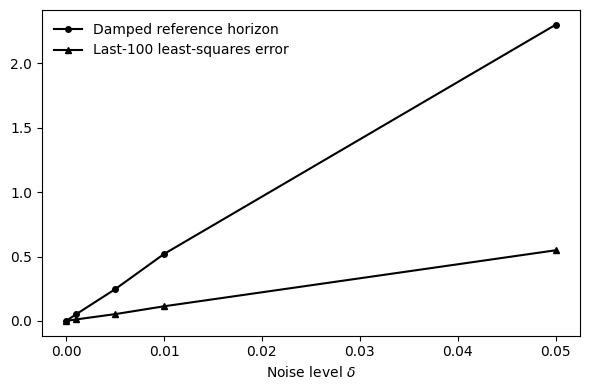

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(deltas, [r[1] for r in rows], color='black', marker='o', linewidth=1.5,
         markersize=4, label='Damped reference horizon')
plt.plot(deltas, [r[2] for r in rows], color='black', marker='^', linewidth=1.5,
         markersize=4, label='Last-100 least-squares error')
plt.xlabel(r'Noise level $\delta$')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('sdtrk_noise_scaling_horizon.png', dpi=300, bbox_inches='tight')
plt.show()